# Project - Data Mining

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Problem 1: Clustering

## A leading bank wants to develop a customer segmentation to give promotional offers to its customers. They collected a sample that summarizes the activities of users during the past few months. You are given the task to identify the segments based on credit card usage.
## Dataset for Problem 1: bank_marketing_part1_Data.csv

## 1.1 Read the data and do exploratory data analysis. Describe the data briefly.

In [2]:
df1 = pd.read_csv('bank_marketing_part1_Data.csv')

In [3]:
df1.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
0,19.94,16.92,0.8752,6.675,3.763,3.252,6.550
1,15.99,14.89,0.9064,5.363,3.582,3.336,5.144
2,18.95,16.42,0.8829,6.248,3.755,3.368,6.148
3,10.83,12.96,0.8099,5.278,2.641,5.182,5.185
4,17.99,15.86,0.8992,5.890,3.694,2.068,5.837


In [4]:
df1.shape

(210, 7)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
spending                        210 non-null float64
advance_payments                210 non-null float64
probability_of_full_payment     210 non-null float64
current_balance                 210 non-null float64
credit_limit                    210 non-null float64
min_payment_amt                 210 non-null float64
max_spent_in_single_shopping    210 non-null float64
dtypes: float64(7)
memory usage: 11.6 KB


In [6]:
df1.describe(include='all')

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


In [7]:
df1.isna().sum()

spending                        0
advance_payments                0
probability_of_full_payment     0
current_balance                 0
credit_limit                    0
min_payment_amt                 0
max_spent_in_single_shopping    0
dtype: int64

In [8]:
dups = df1.duplicated().sum()
dups

0

In [9]:
df1.quantile(0.75)-df1.quantile(0.25)

spending                        5.035000
advance_payments                2.265000
probability_of_full_payment     0.030875
current_balance                 0.717500
credit_limit                    0.617750
min_payment_amt                 2.207250
max_spent_in_single_shopping    0.832000
dtype: float64

In [10]:
df1.var()

spending                        8.466351
advance_payments                1.705528
probability_of_full_payment     0.000558
current_balance                 0.196305
credit_limit                    0.142668
min_payment_amt                 2.260684
max_spent_in_single_shopping    0.241553
dtype: float64

In [11]:
df1.skew()

spending                        0.399889
advance_payments                0.386573
probability_of_full_payment    -0.537954
current_balance                 0.525482
credit_limit                    0.134378
min_payment_amt                 0.401667
max_spent_in_single_shopping    0.561897
dtype: float64

(array([1, 2, 3, 4, 5, 6, 7]), <a list of 7 Text xticklabel objects>)

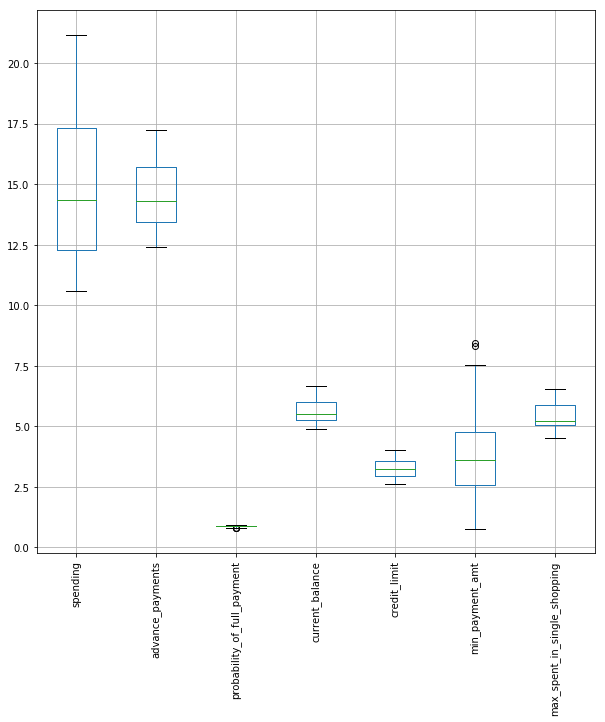

In [12]:
df1.boxplot(figsize=(10,10))
plt.xticks(rotation=90)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000008091C72748>,
      dtype=object)

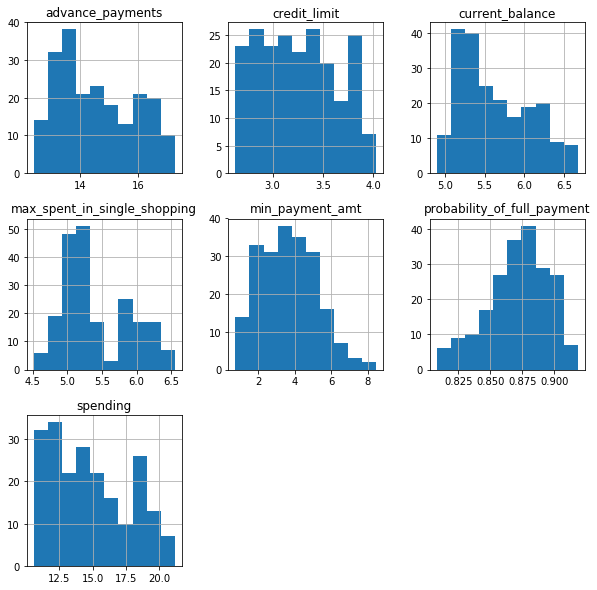

In [13]:
df1.hist(figsize=(10,10))

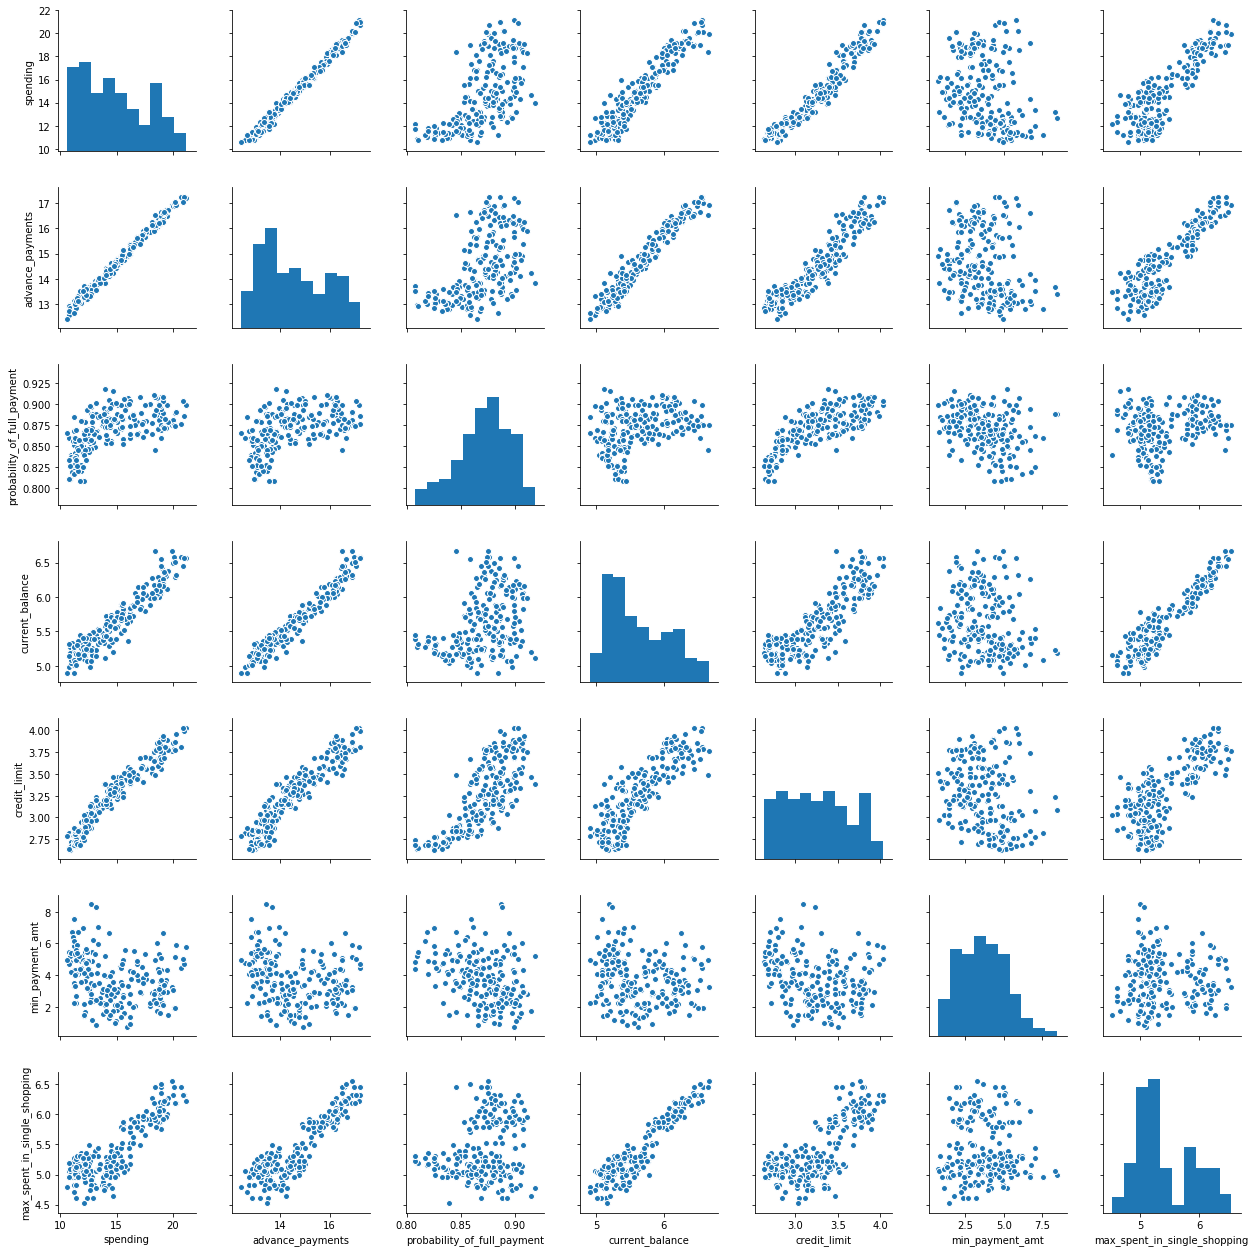

In [14]:
sns.pairplot(df1)

In [15]:
df1.cov()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
spending,8.466351,3.778443,0.041823,1.224704,1.066911,-1.004356,1.235133
advance_payments,3.778443,1.705528,0.016332,0.562666,0.466065,-0.426766,0.571753
probability_of_full_payment,0.041823,0.016332,0.000558,0.003852,0.006798,-0.011777,0.002634
current_balance,1.224704,0.562666,0.003852,0.196305,0.143992,-0.114290,0.203125
credit_limit,1.066911,0.466065,0.006798,0.143992,0.142668,-0.146543,0.139068
min_payment_amt,-1.004356,-0.426766,-0.011777,-0.114290,-0.146543,2.260684,-0.008187
max_spent_in_single_shopping,1.235133,0.571753,0.002634,0.203125,0.139068,-0.008187,0.241553


In [16]:
df1.corr()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
spending,1.000000,0.994341,0.608288,0.949985,0.970771,-0.229572,0.863693
advance_payments,0.994341,1.000000,0.529244,0.972422,0.944829,-0.217340,0.890784
probability_of_full_payment,0.608288,0.529244,1.000000,0.367915,0.761635,-0.331471,0.226825
current_balance,0.949985,0.972422,0.367915,1.000000,0.860415,-0.171562,0.932806
credit_limit,0.970771,0.944829,0.761635,0.860415,1.000000,-0.258037,0.749131
min_payment_amt,-0.229572,-0.217340,-0.331471,-0.171562,-0.258037,1.000000,-0.011079
max_spent_in_single_shopping,0.863693,0.890784,0.226825,0.932806,0.749131,-0.011079,1.000000


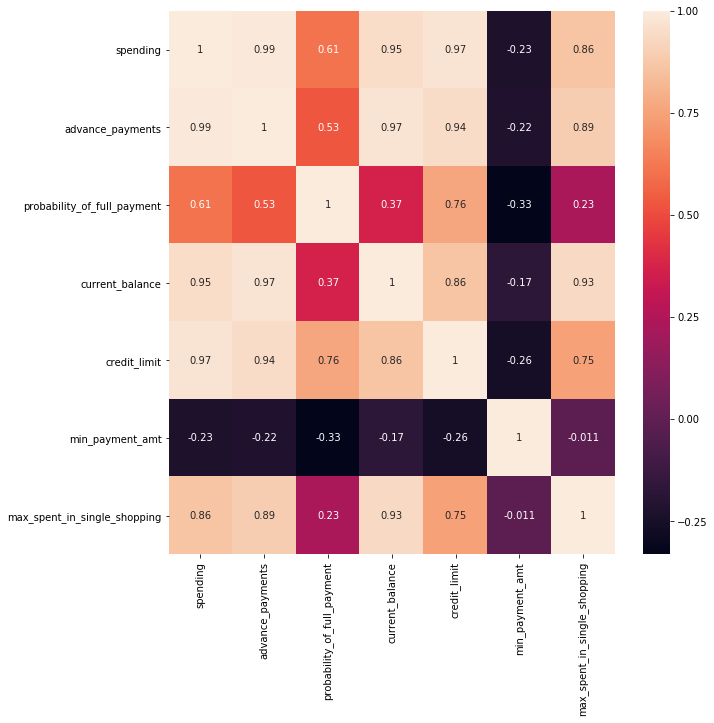

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(df1.corr(), annot = True)

## 1.2  Do you think scaling is necessary for clustering in this case? Justify

### The goal of scaling is to transform features to be on a similar scale. This improves the performance and training stability of the model.
### Z-score is a variation of scaling that represents the number of standard deviations away from the mean.
### We would use z-score to ensure that feature distributions have mean = 0 and std = 1.
### Standardizing the features so that they are centered around 0 with a standard deviation of 1 is important if we are comparing measurements that have different units.

## 1.3 Apply hierarchical clustering to scaled data. Identify the number of optimum clusters using Dendrogram and briefly describe them

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
X = StandardScaler()

In [20]:
df1_scaled = X.fit_transform(df1)

In [21]:
df1_scaled

array([[ 1.75435461,  1.81196782,  0.17822987, ...,  1.33857863,
        -0.29880602,  2.3289982 ],
       [ 0.39358228,  0.25383997,  1.501773  , ...,  0.85823561,
        -0.24280501, -0.53858174],
       [ 1.41330028,  1.42819249,  0.50487353, ...,  1.317348  ,
        -0.22147129,  1.50910692],
       ...,
       [-0.2816364 , -0.30647202,  0.36488339, ..., -0.15287318,
        -1.3221578 , -0.83023461],
       [ 0.43836719,  0.33827054,  1.23027698, ...,  0.60081421,
        -0.95348449,  0.07123789],
       [ 0.24889256,  0.45340314, -0.77624835, ..., -0.07325831,
        -0.70681338,  0.96047321]])

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [23]:
wardlink = linkage(df1_scaled, method = 'ward')

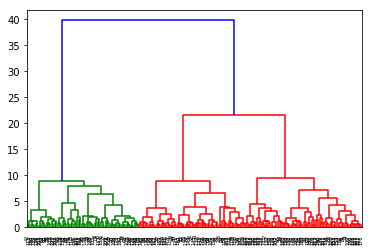

In [24]:
dend = dendrogram(wardlink)

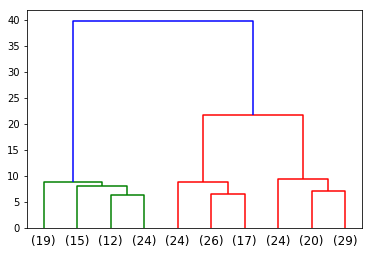

In [25]:
dend = dendrogram(wardlink, truncate_mode= 'lastp', p = 10)

In [26]:
from scipy.cluster.hierarchy import fcluster

In [27]:
clusters = fcluster(wardlink, 3 , criterion='maxclust')
clusters

array([1, 3, 1, 2, 1, 2, 2, 3, 1, 2, 1, 3, 2, 1, 3, 2, 3, 2, 3, 2, 2, 2,
       1, 2, 3, 1, 3, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 1, 1, 3, 1, 1,
       2, 2, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 3, 2, 2, 3, 3, 1,
       1, 3, 1, 2, 3, 2, 1, 1, 2, 1, 3, 2, 1, 3, 3, 3, 3, 1, 2, 3, 3, 1,
       1, 2, 3, 1, 3, 2, 2, 1, 1, 1, 2, 1, 2, 1, 3, 1, 3, 1, 1, 2, 2, 1,
       3, 3, 1, 2, 2, 1, 3, 3, 2, 1, 3, 2, 2, 2, 3, 3, 1, 2, 3, 3, 2, 3,
       3, 1, 2, 1, 1, 2, 1, 3, 3, 3, 2, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 3,
       3, 3, 3, 2, 3, 1, 1, 2, 1, 1, 1, 2, 1, 3, 3, 3, 3, 2, 3, 1, 1, 1,
       3, 3, 1, 2, 3, 3, 3, 3, 1, 1, 3, 3, 3, 2, 3, 3, 2, 1, 3, 1, 1, 2,
       1, 2, 3, 1, 3, 2, 1, 3, 1, 3, 1, 3], dtype=int32)

In [28]:
clusters = fcluster(wardlink, 15 , criterion='distance')
clusters

array([1, 3, 1, 2, 1, 2, 2, 3, 1, 2, 1, 3, 2, 1, 3, 2, 3, 2, 3, 2, 2, 2,
       1, 2, 3, 1, 3, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 1, 1, 3, 1, 1,
       2, 2, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 3, 2, 2, 3, 3, 1,
       1, 3, 1, 2, 3, 2, 1, 1, 2, 1, 3, 2, 1, 3, 3, 3, 3, 1, 2, 3, 3, 1,
       1, 2, 3, 1, 3, 2, 2, 1, 1, 1, 2, 1, 2, 1, 3, 1, 3, 1, 1, 2, 2, 1,
       3, 3, 1, 2, 2, 1, 3, 3, 2, 1, 3, 2, 2, 2, 3, 3, 1, 2, 3, 3, 2, 3,
       3, 1, 2, 1, 1, 2, 1, 3, 3, 3, 2, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 3,
       3, 3, 3, 2, 3, 1, 1, 2, 1, 1, 1, 2, 1, 3, 3, 3, 3, 2, 3, 1, 1, 1,
       3, 3, 1, 2, 3, 3, 3, 3, 1, 1, 3, 3, 3, 2, 3, 3, 2, 1, 3, 1, 1, 2,
       1, 2, 3, 1, 3, 2, 1, 3, 1, 3, 1, 3], dtype=int32)

In [29]:
df1['H_Clusters'] = clusters

In [30]:
df1.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping,H_Clusters
0,19.94,16.92,0.8752,6.675,3.763,3.252,6.550,1
1,15.99,14.89,0.9064,5.363,3.582,3.336,5.144,3
2,18.95,16.42,0.8829,6.248,3.755,3.368,6.148,1
3,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,2
4,17.99,15.86,0.8992,5.890,3.694,2.068,5.837,1


## 1.4 Apply K-Means clustering on scaled data and determine optimum clusters. Apply elbow curve and silhouette score.

In [31]:
from sklearn.cluster import KMeans

In [32]:
wss = []

In [33]:
for i in range(1,11):
    KM = KMeans(n_clusters=i)
    KM.fit(df1_scaled)
    wss.append(KM.inertia_)

In [34]:
wss

[1470.0,
 659.1717544870406,
 430.6589731513006,
 371.65314399951626,
 326.36254154106985,
 289.3608470485393,
 263.75826156674566,
 241.1433066771143,
 223.4894738301418,
 205.80303690619962]

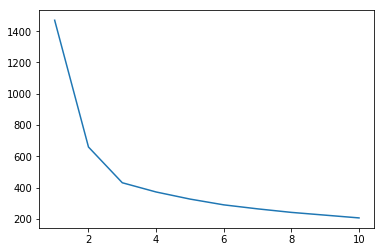

In [35]:
plt.plot(range(1,11), wss)

In [36]:
k_means = KMeans(n_clusters = 3)
k_means.fit(df1_scaled)
labels = k_means.labels_

In [37]:
df1['K_Means'] = labels

In [38]:
df1.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping,H_Clusters,K_Means
0,19.94,16.92,0.8752,6.675,3.763,3.252,6.550,1,2
1,15.99,14.89,0.9064,5.363,3.582,3.336,5.144,3,1
2,18.95,16.42,0.8829,6.248,3.755,3.368,6.148,1,2
3,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,2,0
4,17.99,15.86,0.8992,5.890,3.694,2.068,5.837,1,2


In [39]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [40]:
silhouette_score(df1_scaled, labels)

0.4007270552751299

In [41]:
sil_width = silhouette_samples(df1_scaled, labels)

In [42]:
df1['Silwidth'] = sil_width

In [43]:
df1.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping,H_Clusters,K_Means,Silwidth
0,19.94,16.92,0.8752,6.675,3.763,3.252,6.550,1,2,0.573699
1,15.99,14.89,0.9064,5.363,3.582,3.336,5.144,3,1,0.366386
2,18.95,16.42,0.8829,6.248,3.755,3.368,6.148,1,2,0.637784
3,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,2,0,0.512458
4,17.99,15.86,0.8992,5.890,3.694,2.068,5.837,1,2,0.362276


In [44]:
df1.to_csv('clustering.csv')

## 1.5 Describe cluster profiles for the clusters defined. Recommend different promotional strategies for different clusters.

### Below is the average of each variables based on each cluster
Cluster 1:

    Average spending - 	18.37
    Advance Payment -	16.14
    Prob of full payment -	0.88
    Current balance - 	6.15
    Credit Limit - 		3.68
    min payment amt - 	3.63
    Max spent in single sh- 6.01

Cluster 2:

    Average spending - 	11.87
    Advance Payment -	13.25
    Prob of full payment -	0.84
    Current balance - 	5.23
    Credit Limit - 		2.84
    min payment amt - 	4.94
    Max spent in single sh- 5.12

Cluster 3:

    Average spending - 	14.19
    Advance Payment -	14.23
    Prob of full payment -	0.87
    Current balance - 	5.47
    Credit Limit - 		3.22
    min payment amt - 	2.61
    Max spent in single sh- 5.08


### The Bank is required to develop a customer segmentation to give promotional offer to its customers.

### The Bank has to attract the customers with low spendings by providing them promotional offers. Hence the bank has to focus more on customers who belong to clusters with low spendings.

### The probability of full payment is almost similar across all clusters. Hence there is no requirement to focus on this variable.

### We can also observe from above table that the customers with high average spendings have a higher credit limit. Hence bank needs to think on increasing the credit limit for customers belonging to other clusters to increase their spendings.

### We can also infer that, the customers in cluster 1 spend almost 50% of their credit limit. The customers in cluster 2 and cluster 3 spend less than 50% of their credit limit. Hence Bank may need to consider providing more promotional offers to the customers belonging to Cluster 2 and Cluster 3 to make them utilize most of the credit limit.

# Problem 2: CART-RF-ANN

## An Insurance firm providing tour insurance is facing higher claim frequency. The management decides to collect data from the past few years. You are assigned the task to make a model which predicts the claim status and provide recommendations to management. Use CART, RF & ANN and compare the models' performances in train and test sets.

## Dataset for Problem 2: insurance_part2_data-1.csv

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## 2.1 Data Ingestion: Read the dataset. Do the descriptive statistics and do null value condition check, write an inference on it.

In [127]:
df2 = pd.read_csv('insurance_part2_data.csv')

In [128]:
df2.head()

,Age,Agency_Code,Type,Claimed,Commision,Channel,Duration,Sales,Product Name,Destination
0,48,C2B,Airlines,No,0.70,Online,7,2.51,Customised Plan,ASIA
1,36,EPX,Travel Agency,No,0.00,Online,34,20.00,Customised Plan,ASIA
2,39,CWT,Travel Agency,No,5.94,Online,3,9.90,Customised Plan,Americas
3,36,EPX,Travel Agency,No,0.00,Online,4,26.00,Cancellation Plan,ASIA
4,33,JZI,Airlines,No,6.30,Online,53,18.00,Bronze Plan,ASIA


In [129]:
df2.shape

(3000, 10)

In [130]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
Age             3000 non-null int64
Agency_Code     3000 non-null object
Type            3000 non-null object
Claimed         3000 non-null object
Commision       3000 non-null float64
Channel         3000 non-null object
Duration        3000 non-null int64
Sales           3000 non-null float64
Product Name    3000 non-null object
Destination     3000 non-null object
dtypes: float64(2), int64(2), object(6)
memory usage: 234.5+ KB


In [131]:
df2.describe(include='all')

,Age,Agency_Code,Type,Claimed,Commision,Channel,Duration,Sales,Product Name,Destination
count,3000.000000,3000,3000,3000,3000.000000,3000,3000.000000,3000.000000,3000,3000
unique,NaN,4,2,2,NaN,2,NaN,NaN,5,3
top,NaN,EPX,Travel Agency,No,NaN,Online,NaN,NaN,Customised Plan,ASIA
freq,NaN,1365,1837,2076,NaN,2954,NaN,NaN,1136,2465
mean,38.091000,NaN,NaN,NaN,14.529203,NaN,70.001333,60.249913,NaN,NaN
std,10.463518,NaN,NaN,NaN,25.481455,NaN,134.053313,70.733954,NaN,NaN
min,8.000000,NaN,NaN,NaN,0.000000,NaN,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,0.000000,NaN,11.000000,20.000000,NaN,NaN
50%,36.000000,NaN,NaN,NaN,4.630000,NaN,26.500000,33.000000,NaN,NaN
75%,42.000000,NaN,NaN,NaN,17.235000,NaN,63.000000,69.000000,NaN,NaN


In [132]:
df2.isna().sum()

Age             0
Agency_Code     0
Type            0
Claimed         0
Commision       0
Channel         0
Duration        0
Sales           0
Product Name    0
Destination     0
dtype: int64

In [133]:
df2.duplicated().sum()

139

In [134]:
for feature in df2:
    print(feature.upper(), ': ', df2[feature].nunique())
    print(df2[feature].value_counts().sort_values())
    print('\n')

AGE :  70
8       1
14      1
83      1
77      1
84      1
15      1
11      1
79      2
75      2
16      2
81      2
18      2
76      2
73      3
17      3
70      3
66      5
72      6
71      6
74      7
19      7
62      9
68      9
20     10
63     12
67     12
69     14
55     15
59     15
65     15
     ... 
52     29
50     32
42     34
53     35
47     35
43     35
23     35
22     36
46     40
40     43
41     43
24     43
45     43
33     45
39     46
38     48
44     49
27     54
34     56
37     59
29     66
32     70
26     71
25     73
28     85
35     94
30     96
48    108
31    125
36    999
Name: Age, Length: 70, dtype: int64


AGENCY_CODE :  4
JZI     239
CWT     472
C2B     924
EPX    1365
Name: Agency_Code, dtype: int64


TYPE :  2
Airlines         1163
Travel Agency    1837
Name: Type, dtype: int64


CLAIMED :  2
Yes     924
No     2076
Name: Claimed, dtype: int64


COMMISION :  324
126.75       1
12.45        1
46.80        1
21.35        1
17.55        1
34.

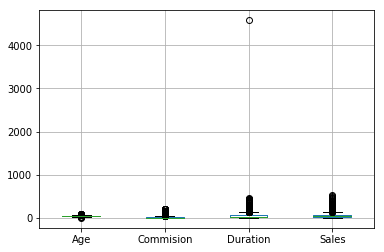

In [135]:
df2.boxplot()

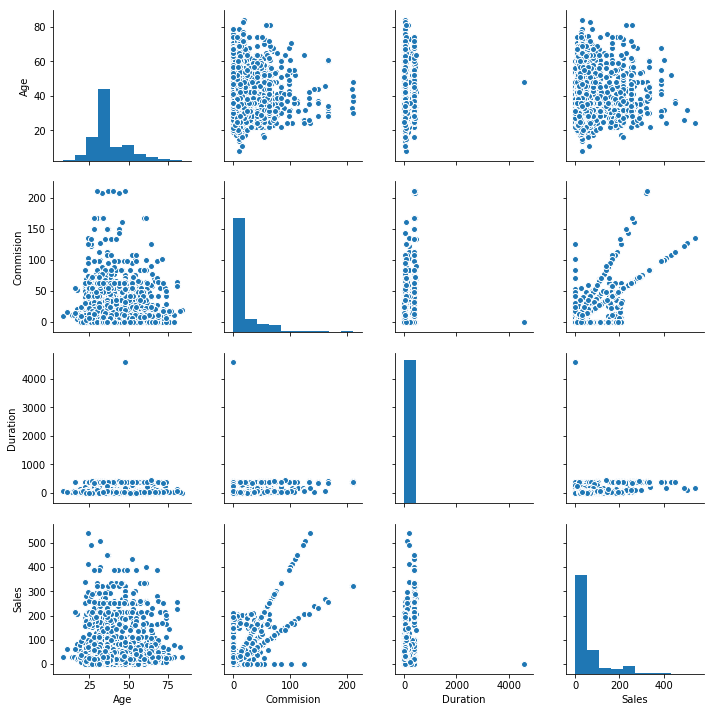

In [136]:
sns.pairplot(df2)

In [137]:
df2.cov()

,Age,Commision,Duration,Sales
Age,109.485214,18.055091,42.676437,29.201372
Commision,18.055091,649.304524,1610.204119,1381.552303
Duration,42.676437,1610.204119,17970.290762,5299.841484
Sales,29.201372,1381.552303,5299.841484,5003.292182


In [138]:
df2.corr()

,Age,Commision,Duration,Sales
Age,1.000000,0.067717,0.030425,0.039455
Commision,0.067717,1.000000,0.471389,0.766505
Duration,0.030425,0.471389,1.000000,0.558930
Sales,0.039455,0.766505,0.558930,1.000000


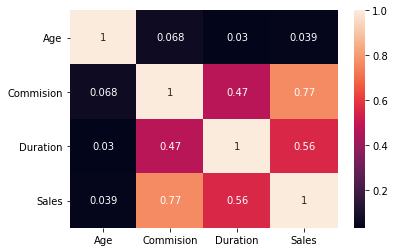

In [139]:
sns.heatmap(df2.corr(), annot = True)

### converting Object type to Integer type

In [140]:
for feature in df2:
    if df2[feature].dtype == 'object':
        df2[feature] = pd.Categorical(df2[feature]).codes

In [141]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
Age             3000 non-null int64
Agency_Code     3000 non-null int8
Type            3000 non-null int8
Claimed         3000 non-null int8
Commision       3000 non-null float64
Channel         3000 non-null int8
Duration        3000 non-null int64
Sales           3000 non-null float64
Product Name    3000 non-null int8
Destination     3000 non-null int8
dtypes: float64(2), int64(2), int8(6)
memory usage: 111.4 KB


In [142]:
df2.Claimed.value_counts(normalize = True)

0    0.692
1    0.308
Name: Claimed, dtype: float64

## 2.2 Data Split: Split the data into test and train, build classification model CART, Random Forest, Artificial Neural Network

In [143]:
X = df2.drop("Claimed", axis=1)

y = df2.pop("Claimed")

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=0)

In [145]:
print('X_train',X_train.shape)
print('X_test',X_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (2100, 9)
X_test (900, 9)
y_train (2100,)
y_test (900,)


In [146]:
from sklearn.model_selection import GridSearchCV

## Decision Tree

In [147]:
dtcl = DecisionTreeClassifier()

In [148]:
param_grid = {
    'criterion': ['gini'],
    'max_depth': [4,6,8,10],
    'min_samples_leaf': [30,60,100,150],
    'min_samples_split': [45,90,150,200],
    'random_state': [0]
}

grid_search = GridSearchCV(estimator = dtcl, param_grid = param_grid, cv = 3)

In [149]:
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 30, 'min_samples_split': 150, 'random_state': 0}


In [150]:
best_grid_dtcl = grid_search.best_estimator_
best_grid_dtcl

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=30, min_samples_split=150,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [151]:
print (pd.DataFrame(best_grid_dtcl.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values('Imp',ascending=False))

                   Imp
Agency_Code   0.626710
Sales         0.264199
Product Name  0.088908
Commision     0.011699
Duration      0.008485
Age           0.000000
Type          0.000000
Channel       0.000000
Destination   0.000000


## Random Forest Classifier

In [152]:
rfcl = RandomForestClassifier()

In [153]:
param_grid = {
    'max_depth': [4,6,8],
    'max_features': [4, 6],
    'min_samples_leaf': [30,60,100],
    'min_samples_split': [90,180,300],
    'n_estimators': [101, 301],
    'random_state': [0]
}

In [154]:
grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid, cv = 3)

In [155]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, error_score='raise',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'max_depth': [4, 6, 8], 'max_features': [4, 6], 'min_samples_leaf': [30, 60, 100], 'min_samples_split': [90, 180, 300], 'n_estimators': [101, 301], 'random_state': [0]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [156]:
grid_search.best_params_

{'max_depth': 6,
 'max_features': 4,
 'min_samples_leaf': 30,
 'min_samples_split': 180,
 'n_estimators': 301,
 'random_state': 0}

In [157]:
best_grid_rfcl = grid_search.best_estimator_
best_grid_rfcl

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=6, max_features=4, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=30, min_samples_split=180,
            min_weight_fraction_leaf=0.0, n_estimators=301, n_jobs=1,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [159]:
print (pd.DataFrame(best_grid_rfcl.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values('Imp',ascending=False))

                   Imp
Agency_Code   0.346448
Product Name  0.272245
Sales         0.169082
Commision     0.109182
Duration      0.042664
Type          0.038669
Age           0.013375
Destination   0.008335
Channel       0.000000


## ANN

In [160]:
nncl = MLPClassifier()

In [161]:
param_grid = {
    'hidden_layer_sizes': [50,100,200],
    'max_iter': [10000],
    'solver': ['sgd','adam'],
    'tol': [0.01, 0.01], 
    'random_state': [0]
}

In [162]:
grid_search = GridSearchCV(estimator = nncl, param_grid = param_grid, cv = 3)

In [163]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, error_score='raise',
       estimator=MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(100,), learning_rate='constant',
       learning_rate_init=0.001, max_iter=200, momentum=0.9,
       nesterovs_momentum=True, power_t=0.5, random_state=None,
       shuffle=True, solver='adam', tol=0.0001, validation_fraction=0.1,
       verbose=False, warm_start=False),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'hidden_layer_sizes': [50, 100, 200], 'max_iter': [10000], 'solver': ['sgd', 'adam'], 'tol': [0.01, 0.01], 'random_state': [0]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [164]:
grid_search.best_params_

{'hidden_layer_sizes': 200,
 'max_iter': 10000,
 'random_state': 0,
 'solver': 'adam',
 'tol': 0.01}

In [165]:
best_grid_ann = grid_search.best_estimator_
best_grid_ann

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=200, learning_rate='constant',
       learning_rate_init=0.001, max_iter=10000, momentum=0.9,
       nesterovs_momentum=True, power_t=0.5, random_state=0, shuffle=True,
       solver='adam', tol=0.01, validation_fraction=0.1, verbose=False,
       warm_start=False)

## 2.3 Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model

### Y train/Y test predict and Y train/Y test predict probability

### Decision Tree

In [166]:
ytrain_predict_dtcl = best_grid_dtcl.predict(X_train)
ytest_predict_dtcl = best_grid_dtcl.predict(X_test)

ytrain_predict_prob_dtcl = best_grid_dtcl.predict_proba(X_train)
ytest_predict_prob_dtcl = best_grid_dtcl.predict_proba(X_test)

### Random Forest Classifier

In [167]:
ytrain_predict_rfcl = best_grid_rfcl.predict(X_train)
ytest_predict_rfcl = best_grid_rfcl.predict(X_test)

ytrain_predict_prob_rfcl = best_grid_rfcl.predict_proba(X_train)
ytest_predict_prob_rfcl = best_grid_rfcl.predict_proba(X_test)

### ANN

In [168]:
ytrain_predict_ann = best_grid_ann.predict(X_train)
ytest_predict_ann = best_grid_ann.predict(X_test)

ytrain_predict_prob_ann = best_grid_ann.predict_proba(X_train)
ytest_predict_prob_ann = best_grid_ann.predict_proba(X_test)

In [169]:
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix

### AUC Score, AUC_ROC_Curve

### Decision Tree

### Training Data set

AUC: 0.810


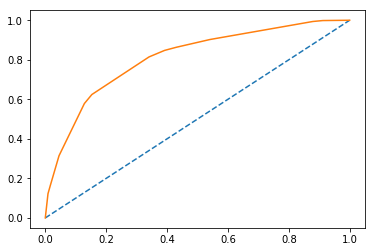

In [170]:
# keep probabilities for the positive outcome only
probs = ytrain_predict_prob_dtcl[:, 1]
# calculate AUC
cart_train_auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % cart_train_auc)
# calculate roc curve
cart_train_fpr, cart_train_tpr, cart_train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(cart_train_fpr, cart_train_tpr)

### Testing Data set

AUC: 0.815


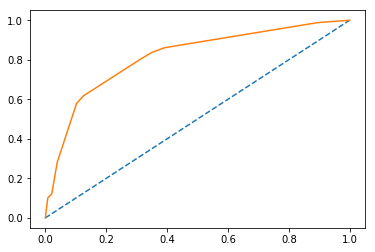

In [171]:
# keep probabilities for the positive outcome only
probs = ytest_predict_prob_dtcl[:, 1]
# calculate AUC
cart_test_auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % cart_test_auc)
# calculate roc curve
cart_test_fpr, cart_test_tpr, cart_test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(cart_test_fpr, cart_test_tpr)

### Random Forest Classifier

### Training Data set

AUC: 0.825


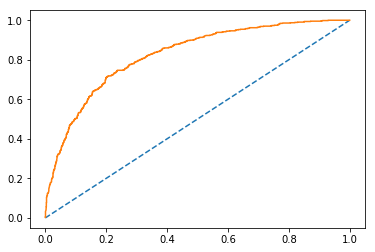

In [172]:
probs = ytrain_predict_prob_rfcl[:, 1]
# calculate AUC
rfcl_train_auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % rfcl_train_auc)
# calculate roc curve
rfcl_train_fpr, rfcl_train_tpr, rfcl_train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(rfcl_train_fpr, rfcl_train_tpr)

### Testing Data set

AUC: 0.837


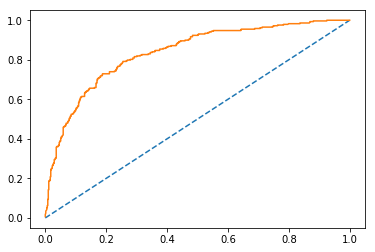

In [173]:
probs = ytest_predict_prob_rfcl[:, 1]
# calculate AUC
rfcl_test_auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % rfcl_test_auc)
# calculate roc curve
rfcl_test_fpr, rfcl_test_tpr, rfcl_test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(rfcl_test_fpr, rfcl_test_tpr)

### ANN

### Training Data set

AUC: 0.802


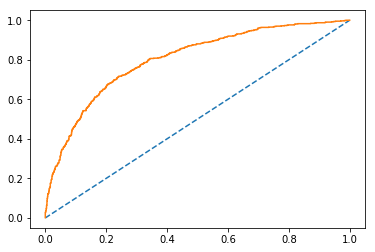

In [174]:
probs = ytrain_predict_prob_ann[:, 1]
# calculate AUC
ann_train_auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % ann_train_auc)
# calculate roc curve
ann_train_fpr, ann_train_tpr, ann_train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(ann_train_fpr, ann_train_tpr)

### Testing Data set

AUC: 0.812


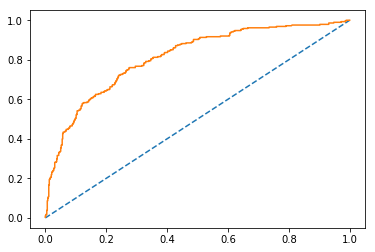

In [175]:
probs = ytest_predict_prob_ann[:, 1]
# calculate AUC
ann_test_auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % ann_test_auc)
# calculate roc curve
ann_test_fpr, ann_test_tpr, ann_test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(ann_test_fpr, ann_test_tpr)

### Confusion Matrix for Training and Testing Data

### Decision Tree

In [176]:
confusion_matrix(y_train, ytrain_predict_dtcl)

array([[1276,  188],
       [ 268,  368]], dtype=int64)

In [177]:
confusion_matrix(y_test, ytest_predict_dtcl)

array([[549,  63],
       [121, 167]], dtype=int64)

### Random Forest Classifier

In [178]:
confusion_matrix(y_train, ytrain_predict_rfcl)

array([[1311,  153],
       [ 312,  324]], dtype=int64)

In [179]:
confusion_matrix(y_test, ytest_predict_rfcl)

array([[560,  52],
       [140, 148]], dtype=int64)

### ANN

In [180]:
confusion_matrix(y_train, ytrain_predict_ann)

array([[1286,  178],
       [ 298,  338]], dtype=int64)

In [181]:
confusion_matrix(y_test, ytest_predict_ann)

array([[544,  68],
       [131, 157]], dtype=int64)

### Classification Report for Training and Testing Data

### Decision Tree

In [182]:
print(classification_report(y_train, ytrain_predict_dtcl))

             precision    recall  f1-score   support

          0       0.83      0.87      0.85      1464
          1       0.66      0.58      0.62       636

avg / total       0.78      0.78      0.78      2100



In [183]:
print(classification_report(y_test, ytest_predict_dtcl))

             precision    recall  f1-score   support

          0       0.82      0.90      0.86       612
          1       0.73      0.58      0.64       288

avg / total       0.79      0.80      0.79       900



### Random Forest Classifier

In [184]:
print(classification_report(y_train, ytrain_predict_rfcl))

             precision    recall  f1-score   support

          0       0.81      0.90      0.85      1464
          1       0.68      0.51      0.58       636

avg / total       0.77      0.78      0.77      2100



In [185]:
print(classification_report(y_test, ytest_predict_rfcl))

             precision    recall  f1-score   support

          0       0.80      0.92      0.85       612
          1       0.74      0.51      0.61       288

avg / total       0.78      0.79      0.77       900



### ANN

In [186]:
print(classification_report(y_train, ytrain_predict_ann))

             precision    recall  f1-score   support

          0       0.81      0.88      0.84      1464
          1       0.66      0.53      0.59       636

avg / total       0.76      0.77      0.77      2100



In [187]:
print(classification_report(y_test, ytest_predict_ann))

             precision    recall  f1-score   support

          0       0.81      0.89      0.85       612
          1       0.70      0.55      0.61       288

avg / total       0.77      0.78      0.77       900



### Accuracy Score for Training and Testing Data

### Decision Tree

In [188]:
#Train Data Accuracy
cart_train_acc=best_grid_dtcl.score(X_train,y_train) 
cart_train_acc

0.7828571428571428

In [189]:
#Test Data Accuracy
cart_test_acc=best_grid_dtcl.score(X_test,y_test)
cart_test_acc

0.7955555555555556

### Random Forest Classifier

In [190]:
#Train Data Accuracy
rfcl_train_acc=best_grid_rfcl.score(X_train,y_train) 
rfcl_train_acc

0.7785714285714286

In [191]:
#Test Data Accuracy
rfcl_test_acc=best_grid_rfcl.score(X_test,y_test)
rfcl_test_acc

0.7866666666666666

### ANN

In [192]:
#Train Data Accuracy
ann_train_acc=best_grid_ann.score(X_train,y_train) 
ann_train_acc

0.7733333333333333

In [193]:
#Test Data Accuracy
ann_test_acc=best_grid_ann.score(X_test,y_test)
ann_test_acc

0.7788888888888889

## 2.4 Final Model: Compare all the model and write an inference which model is best/optimized.

## Decision Tree Classifier Conclusion

<b>Train Data:</b>  
    AUC: 81.0%        
    Accuracy: 78.28%        
    Sensitivity: 58.0%     
    Precision: 66.0%        
    f1-Score: 62.0%       
            
<b>Test Data:</b>      
    AUC: 81.5%      
    Accuracy:79.55%      
    Sensitivity: 58.0%    
    Precision: 73.0%       
    f1-Score: 64.0%     
  
Training and Test set results are almost similar, and with the overall measures high, the model is a good model.  
  
Agency Code is the most important variable for predicting Claim Status

## Random Forest Classifier Conclusion

<b>Train Data:</b>  
    AUC: 82.5%        
    Accuracy: 77.85%        
    Sensitivity: 51.0%     
    Precision: 68.0%        
    f1-Score: 58.0%       
            
<b>Test Data:</b>      
    AUC: 83.7%      
    Accuracy:78.66%      
    Sensitivity: 51.0%    
    Precision: 74.0%       
    f1-Score: 61.0%     
  
Training and Test set results are almost similar, and with the overall measures high, the model is a good model.  
  
Agency Code is the most important variable for predicting Claim Status

## Artificial Neural Network Conclusion

<b>Train Data:</b>  
    AUC: 80.2%        
    Accuracy: 77.33%        
    Sensitivity: 53.0%     
    Precision: 66.0%        
    f1-Score: 59.0%       
            
<b>Test Data:</b>      
    AUC: 81.2%      
    Accuracy:77.88%      
    Sensitivity: 55.0%    
    Precision: 70.0%       
    f1-Score: 61.0%     
  
Training and Test set results are almost similar, and with the overall measures high, the model is a good model.

### Out of the 3 models, Decision Tree Classifier has better recall than the Random Forest Classifier and Artificial Neural Network as the sensitivity or recall is an important factor in this case study.

### Out of the 3 models, Random Forest Classifier has slightly AUC than the Desicison Tree Classifier and Artificial Neural Network.

### Out of the 3 models, Artificial Neural Network has a smaller change in Accuracy of Train-Test Data set, Hence ANN has better performance when compared to other two models.

### Overall, all the 3 models are reasonably stable enough to be used for making any future predictions.

### From Decision Tree and Random Forest Model, the variable Agency Code is found to be the most useful feature amongst all other features for predicting if one has Claimed or not.

## 2.5 Inference: Basis on these predictions, what are the business insights and recommendations

### Based on the above predictions, we can infer that the key feature that the insurance firm needs to consider to infer the claim status.

### The Sales and Product Name are the other two variables which needs to be consider while prediciting the claim status.

### The feature importance of age, destination and channel is almost negligible, or equal to 0. Hence these factors are not contributing much for the predictions.

### The insurance firm can consider the Artificial Neural Network for predicting the future claim status. However, all 3 models have given good results for the above dataset.

### We recommend that the insurance need to consider the safety precautions in order to reduce the claims.